# Phase 2 — Exploratory Data Analysis: US EPU × Multi-Asset Volatility

**Dataset:** `usepu_assets_daily_features.csv` (daily, generated in Phase 1)  
**Assets:** S&P 500, Gold, Bitcoin  
**Objective:** EDA of the merged dataset — distributions, correlations, lead-lag structure, and regime analysis — prior to any predictive modelling.  
**Scope:** Association analysis only. No causal claims. No machine-learning models.

---

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# ── Plot style ──────────────────────────────────────────────────────
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 11,
    'figure.dpi': 120,
})

COLORS = {
    'epu':   '#1f77b4',
    'sp500': '#d62728',
    'gold':  '#ff7f0e',
    'btc':   '#2ca02c',
    'shock': '#9467bd',
}

ASSET_META = {
    'SP500': {'color': COLORS['sp500'], 'label': 'S&P 500'},
    'Gold':  {'color': COLORS['gold'],  'label': 'Gold'},
    'BTC':   {'color': COLORS['btc'],   'label': 'Bitcoin'},
}

# ── Data paths ──────────────────────────────────────────────────────
DATA_PROCESSED = Path('../../../../data/processed')

print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
# ── Load dataset ────────────────────────────────────────────────────
df = pd.read_csv(DATA_PROCESSED / 'usepu_assets_daily_features.csv', parse_dates=['Date'])
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

# Set Date as index
df.set_index('Date', inplace=True)
df.index.name = 'Date'

print(f'Dataset loaded: {df.shape[0]} observations, {df.shape[1]} columns')
print(f'Date range: {df.index.min().date()} → {df.index.max().date()}')
print(f'\nColumns: {list(df.columns)}')

Dataset loaded: 2227 observations, 28 columns
Date range: 2014-01-03 → 2023-11-13

Columns: ['EPU', 'ΔEPU', 'EPU_MA30', 'EPU_Std30', 'SP500_Close', 'SP500_Open', 'SP500_High', 'SP500_Low', 'SP500_Return', 'SP500_Vol7d', 'SP500_Vol30d', 'SP500_Vol90d', 'Gold_Close', 'Gold_Open', 'Gold_High', 'Gold_Low', 'Gold_Return', 'Gold_Vol7d', 'Gold_Vol30d', 'Gold_Vol90d', 'BTC_Close', 'BTC_Open', 'BTC_High', 'BTC_Low', 'BTC_Return', 'BTC_Vol7d', 'BTC_Vol30d', 'BTC_Vol90d']


---
## 1. Data Overview — Quality and Structure

Before any analysis we verify the dataset integrity: types, missing values, temporal coverage, and frequency. The daily granularity allows us to analyse high-frequency dynamics between EPU and asset volatilities, but requires checking for weekend/holiday gaps.

In [3]:
df.info()
df.describe().round(4)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2227 entries, 2014-01-03 to 2023-11-13
Data columns (total 28 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   EPU           2227 non-null   float64
 1   ΔEPU          2227 non-null   float64
 2   EPU_MA30      2227 non-null   float64
 3   EPU_Std30     2227 non-null   float64
 4   SP500_Close   2227 non-null   float64
 5   SP500_Open    2227 non-null   float64
 6   SP500_High    2227 non-null   float64
 7   SP500_Low     2227 non-null   float64
 8   SP500_Return  2227 non-null   float64
 9   SP500_Vol7d   2227 non-null   float64
 10  SP500_Vol30d  2227 non-null   float64
 11  SP500_Vol90d  2227 non-null   float64
 12  Gold_Close    2227 non-null   float64
 13  Gold_Open     2227 non-null   float64
 14  Gold_High     2227 non-null   float64
 15  Gold_Low      2227 non-null   float64
 16  Gold_Return   2227 non-null   float64
 17  Gold_Vol7d    2227 non-null   float64
 18  Gold_Vol30

,EPU,ΔEPU,EPU_MA30,EPU_Std30,SP500_Close,SP500_Open,SP500_High,SP500_Low,SP500_Return,SP500_Vol7d,...,Gold_Vol30d,Gold_Vol90d,BTC_Close,BTC_Open,BTC_High,BTC_Low,BTC_Return,BTC_Vol7d,BTC_Vol30d,BTC_Vol90d
count,2227.0000,2227.0000,2227.0000,2227.0000,2227.0000,2227.0000,2227.0000,2227.0000,2227.0000,2227.0000,...,2227.0000,2227.0000,2227.0000,2227.0000,2227.0000,2227.0000,2226.0000,2222.0000,2208.0000,2167.0000
mean,118.7277,-10.4729,124.6516,50.6368,2963.3612,2963.0599,2979.1075,2945.6634,0.0003,0.0090,...,0.0093,0.0095,13239.9913,13231.1410,13598.7279,12831.3221,0.0008,0.0338,0.0379,0.0386
std,93.5754,64.8369,83.5672,25.3069,898.7788,898.6960,904.8026,892.4242,0.0113,0.0073,...,0.0028,0.0022,16286.7163,16288.1064,16751.2456,15772.6222,0.0570,0.0407,0.0374,0.0265
min,3.3200,-381.6700,48.6707,17.9854,1741.9000,1743.8000,1755.8000,1737.9000,-0.1277,0.0011,...,0.0045,0.0062,111.6000,111.9000,160.1000,91.7000,-0.8488,0.0028,0.0070,0.0117
25%,61.1300,-37.9350,75.8113,32.1496,2102.7500,2102.6000,2110.3500,2094.0500,-0.0039,0.0047,...,0.0074,0.0078,598.8500,599.0000,608.9000,587.5500,-0.0145,0.0179,0.0236,0.0272
50%,91.1500,-7.7100,101.1660,44.9735,2765.3000,2773.9000,2782.5000,2748.6000,0.0005,0.0072,...,0.0087,0.0090,6943.6000,6903.5000,7159.7000,6695.1000,0.0007,0.0272,0.0322,0.0337
75%,140.2200,20.5450,136.8438,59.5398,3849.4400,3851.9250,3877.2350,3817.6650,0.0056,0.0110,...,0.0103,0.0108,20587.5000,20724.0500,21195.0000,20220.8000,0.0186,0.0408,0.0424,0.0418
max,807.6600,358.2800,564.0603,190.5023,4796.6000,4804.5000,4818.6000,4780.0000,0.0897,0.0865,...,0.0264,0.0176,67527.9000,67528.7000,68990.6000,66334.9000,1.4742,0.8081,0.3825,0.2223


In [4]:
# ── Temporal range ──────────────────────────────────────────────────
print(f'Min date : {df.index.min().date()}')
print(f'Max date : {df.index.max().date()}')
print(f'Total trading days: {len(df)}')

# Check for duplicate dates
dupes = df.index.duplicated().sum()
print(f'Duplicate dates: {dupes}')

# ── Missing values summary ──────────────────────────────────────────
missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2)
})
missing = missing.sort_values('missing_count', ascending=False)
display(missing[missing['missing_count'] > 0])
print(f'\nColumns with zero missing: {(missing["missing_count"] == 0).sum()}/{len(missing)}')

Min date : 2014-01-03
Max date : 2023-11-13
Total trading days: 2227
Duplicate dates: 0


,missing_count,missing_pct
BTC_Vol90d,60,2.69
BTC_Vol30d,19,0.85
BTC_Vol7d,5,0.22
BTC_Return,1,0.04



Columns with zero missing: 24/28


> **Note on frequency:** This dataset uses daily observations aligned to trading days. Bitcoin trades 365 days/year while S&P 500 and Gold follow the NYSE calendar (~252 days/year). Days where only some assets have data will show NaN for the others. The EPU index is published daily.

---
## 2. Time-Series Visualisation of Core Variables

We inspect the main series individually to identify trends, structural breaks, outlier spikes, and regime changes. Vertical reference lines mark well-known crisis episodes:
- **Sep 2008** — Global Financial Crisis (Lehman Brothers collapse)
- **Mar 2020** — COVID-19 pandemic onset
- **Feb 2022** — Russia-Ukraine war / inflation shock

In [5]:
# ── Helper: vertical crisis lines ──────────────────────────────────
CRISES = {
    '2008-09-15': 'GFC',
    '2020-03-11': 'COVID-19',
    '2022-02-24': 'Ukraine',
}

def add_crisis_lines(ax):
    """Add dashed vertical lines for major crisis dates."""
    for date_str, label in CRISES.items():
        dt = pd.Timestamp(date_str)
        if df.index.min() <= dt <= df.index.max():
            ax.axvline(dt, color='grey', linestyle='--', alpha=0.6, linewidth=0.9)
            ax.text(dt, ax.get_ylim()[1] * 0.97, f' {label}',
                    fontsize=8, color='grey', rotation=90,
                    va='top', ha='right')

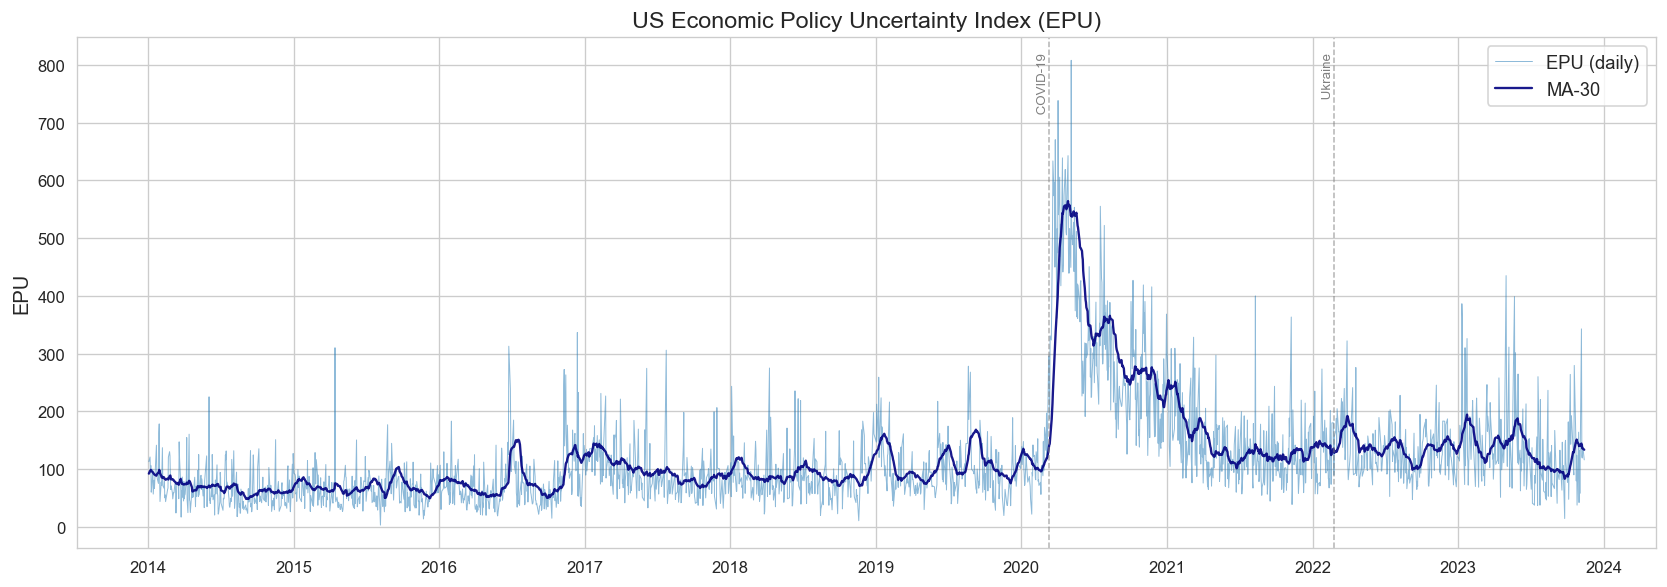

In [6]:
# ── 2a. EPU (level) ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['EPU'], color=COLORS['epu'], linewidth=0.6, alpha=0.5, label='EPU (daily)')
if 'EPU_MA30' in df.columns:
    ax.plot(df.index, df['EPU_MA30'], color='navy', linewidth=1.4,
            linestyle='-', label='MA-30', alpha=0.9)
add_crisis_lines(ax)
ax.set_title('US Economic Policy Uncertainty Index (EPU)')
ax.set_ylabel('EPU')
ax.legend()
plt.tight_layout()
plt.show()

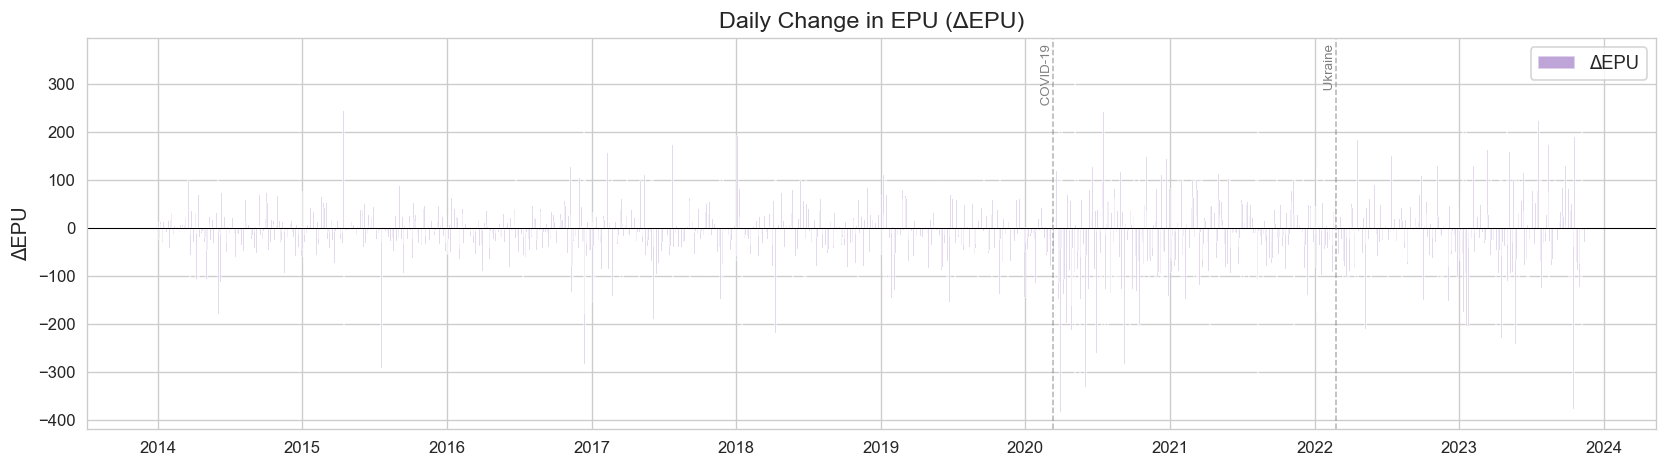

In [7]:
# ── 2b. ΔEPU (shocks) ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(df.index, df['ΔEPU'], width=1, color=COLORS['shock'], alpha=0.6, label='ΔEPU')
ax.axhline(0, color='black', linewidth=0.6)
add_crisis_lines(ax)
ax.set_title('Daily Change in EPU (ΔEPU)')
ax.set_ylabel('ΔEPU')
ax.legend()
plt.tight_layout()
plt.show()

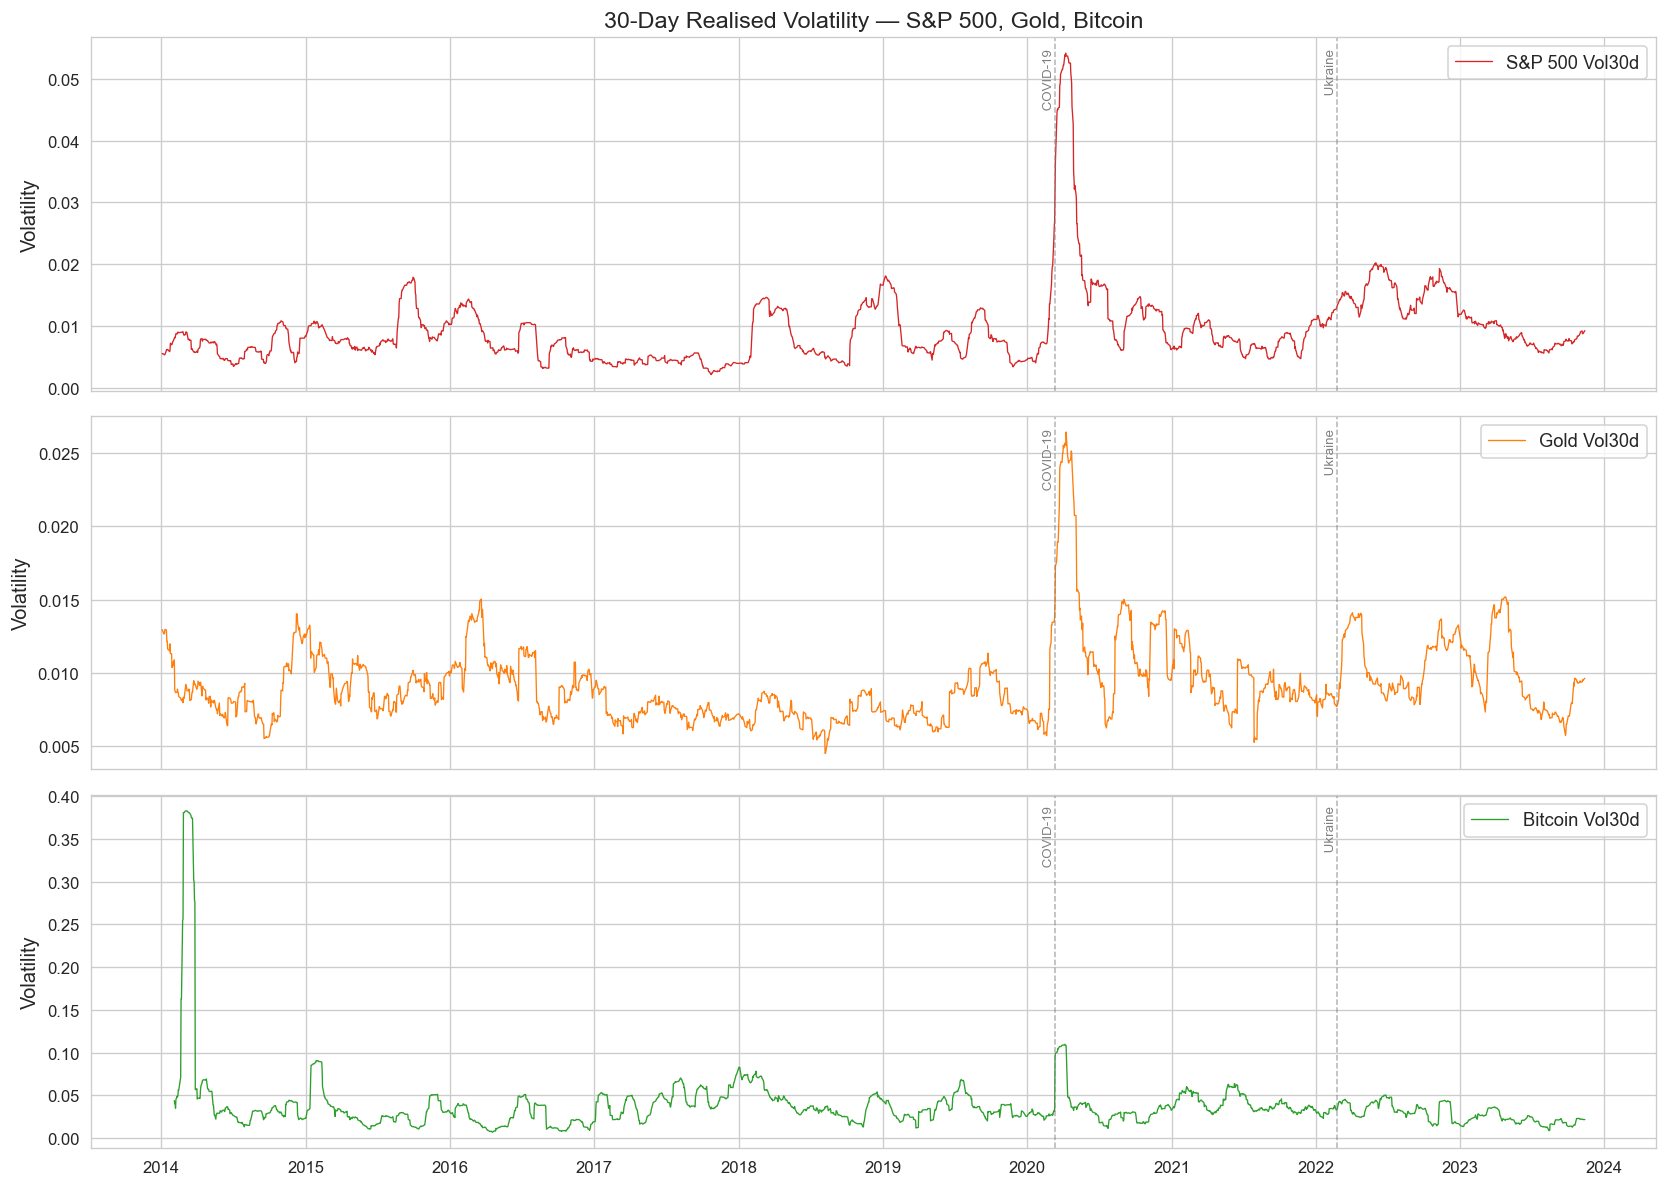

In [8]:
# ── 2c. Asset 30-day Volatilities ──────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, (asset, meta) in zip(axes, ASSET_META.items()):
    vol_col = f'{asset}_Vol30d'
    if vol_col in df.columns:
        ax.plot(df.index, df[vol_col], color=meta['color'], linewidth=0.8,
                label=f'{meta["label"]} Vol30d')
        add_crisis_lines(ax)
        ax.set_ylabel('Volatility')
        ax.legend(loc='upper right')

axes[0].set_title('30-Day Realised Volatility — S&P 500, Gold, Bitcoin')
plt.tight_layout()
plt.show()

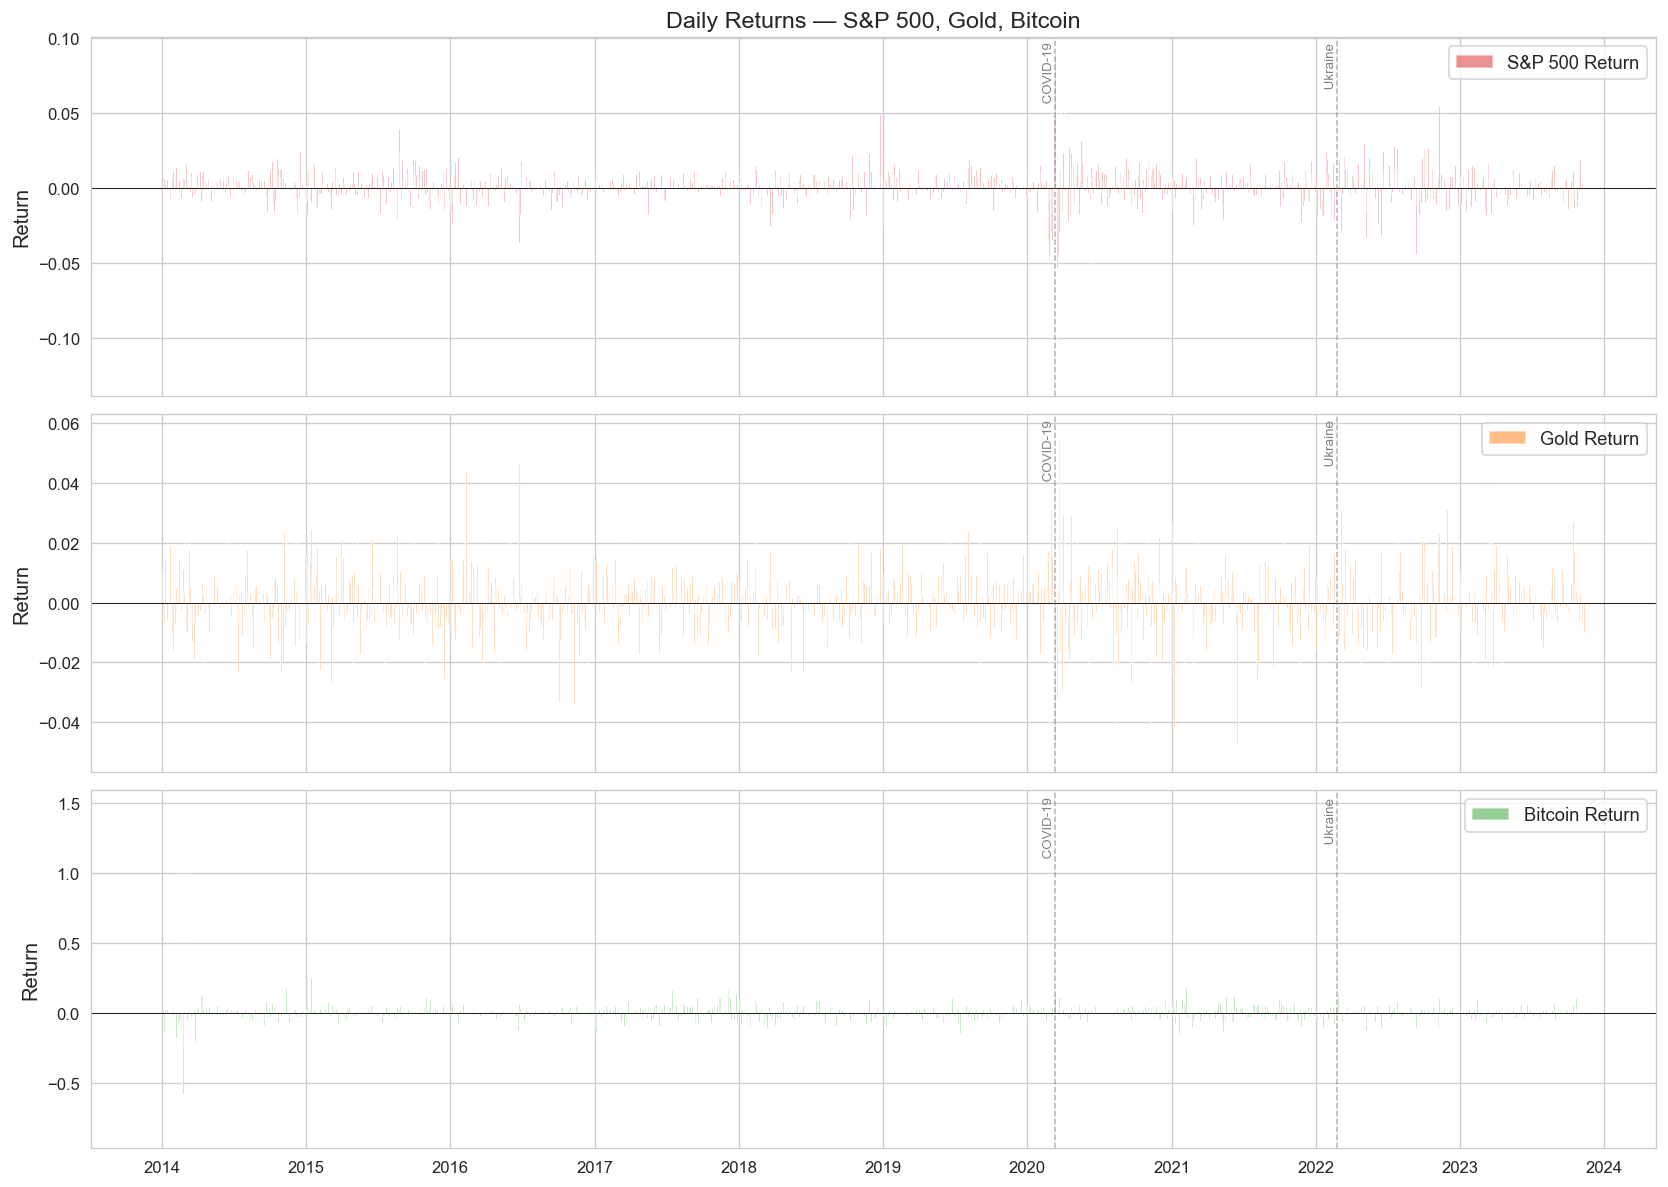

In [9]:
# ── 2d. Asset Returns ──────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, (asset, meta) in zip(axes, ASSET_META.items()):
    ret_col = f'{asset}_Return'
    if ret_col in df.columns:
        ax.bar(df.index, df[ret_col], width=1, color=meta['color'],
               alpha=0.5, label=f'{meta["label"]} Return')
        ax.axhline(0, color='black', linewidth=0.5)
        add_crisis_lines(ax)
        ax.set_ylabel('Return')
        ax.legend(loc='upper right')

axes[0].set_title('Daily Returns — S&P 500, Gold, Bitcoin')
plt.tight_layout()
plt.show()

---
## 3. Distributions and Outliers

Understanding the distributional properties of the key variables is essential before correlation and regression analysis. Heavy tails (high kurtosis) and skewness affect the interpretation of Pearson correlations and OLS standard errors.

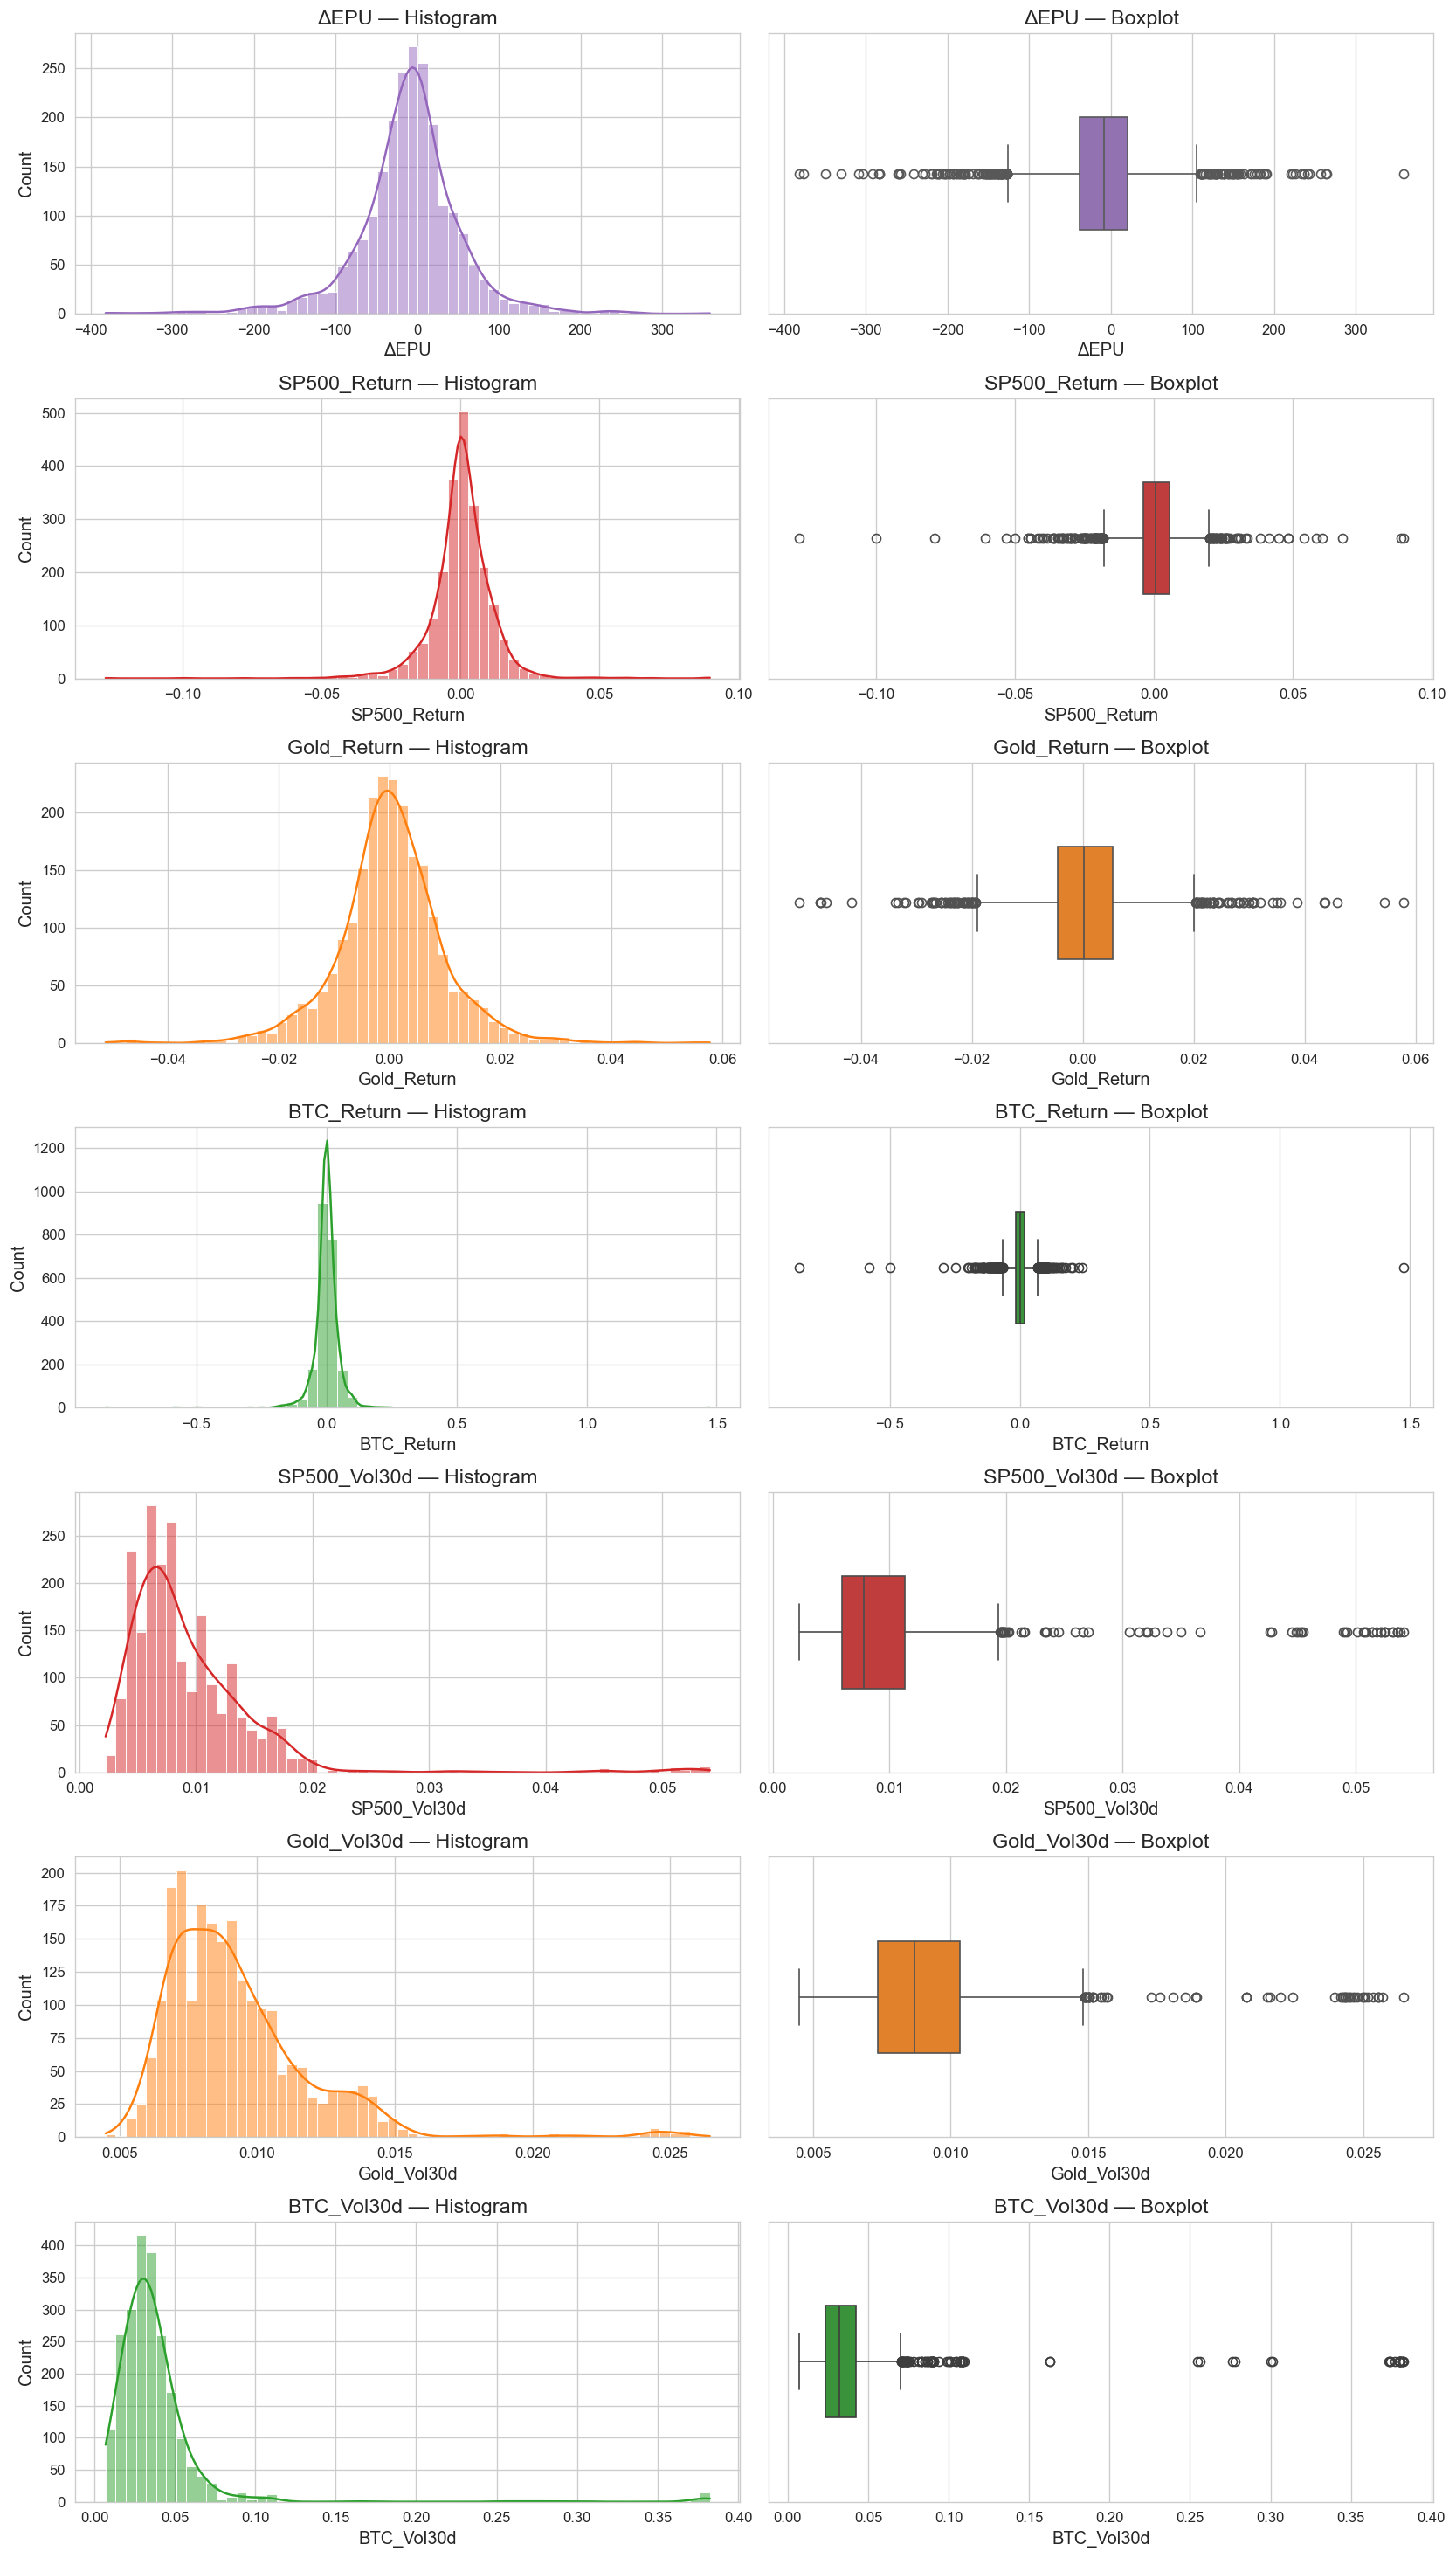

In [10]:
DIST_VARS = ['ΔEPU', 'SP500_Return', 'Gold_Return', 'BTC_Return',
             'SP500_Vol30d', 'Gold_Vol30d', 'BTC_Vol30d']

DIST_COLORS = {
    'ΔEPU':         COLORS['shock'],
    'SP500_Return':  COLORS['sp500'],
    'Gold_Return':   COLORS['gold'],
    'BTC_Return':    COLORS['btc'],
    'SP500_Vol30d':  COLORS['sp500'],
    'Gold_Vol30d':   COLORS['gold'],
    'BTC_Vol30d':    COLORS['btc'],
}

fig, axes = plt.subplots(len(DIST_VARS), 2, figsize=(14, 3.5 * len(DIST_VARS)))

for i, var in enumerate(DIST_VARS):
    data = df[var].dropna()
    c = DIST_COLORS.get(var, '#1f77b4')

    # Histogram + KDE
    ax_h = axes[i, 0]
    sns.histplot(data, bins=60, kde=True, ax=ax_h, color=c)
    ax_h.set_title(f'{var} — Histogram')
    ax_h.set_xlabel(var)

    # Boxplot
    ax_b = axes[i, 1]
    sns.boxplot(x=data, ax=ax_b, color=c, width=0.4)
    ax_b.set_title(f'{var} — Boxplot')
    ax_b.set_xlabel(var)

plt.tight_layout()
plt.show()

In [11]:
# ── Skewness & Kurtosis table ──────────────────────────────────────
from scipy.stats import skew, kurtosis

stats_table = pd.DataFrame({
    'mean':     [df[v].mean() for v in DIST_VARS],
    'std':      [df[v].std() for v in DIST_VARS],
    'skewness': [skew(df[v].dropna()) for v in DIST_VARS],
    'kurtosis': [kurtosis(df[v].dropna(), fisher=True) for v in DIST_VARS],
    'min':      [df[v].min() for v in DIST_VARS],
    'max':      [df[v].max() for v in DIST_VARS],
    'n':        [df[v].notna().sum() for v in DIST_VARS],
}, index=DIST_VARS)

display(stats_table.round(4))

,mean,std,skewness,kurtosis,min,max,n
ΔEPU,-10.4729,64.8369,-0.4248,4.4554,-381.6700,358.2800,2227
SP500_Return,0.0003,0.0113,-0.8384,17.1908,-0.1277,0.0897,2227
Gold_Return,0.0002,0.0096,0.0394,3.6344,-0.0511,0.0578,2227
BTC_Return,0.0008,0.0570,5.3822,230.3945,-0.8488,1.4742,2226
SP500_Vol30d,0.0095,0.0064,3.8562,21.2672,0.0022,0.0541,2227
Gold_Vol30d,0.0093,0.0028,2.3592,9.3173,0.0045,0.0264,2227
BTC_Vol30d,0.0379,0.0374,7.0598,59.1276,0.0070,0.3825,2208


> **Interpretation:** If excess kurtosis > 0, the distribution has heavier tails than a Normal distribution. This is common in financial return and volatility series and implies that extreme observations carry disproportionate influence on Pearson correlations. Spearman (rank-based) correlations are more robust in this setting.

---
## 4. Correlation Analysis (Static)

We compute the full-sample pairwise correlation matrix under two estimators:

1. **Pearson** — captures linear association; sensitive to outliers and non-normality.  
2. **Spearman** — rank-based; robust to non-linear monotone relationships and heavy tails.

Divergence between the two matrices signals non-linearity or influential outliers.

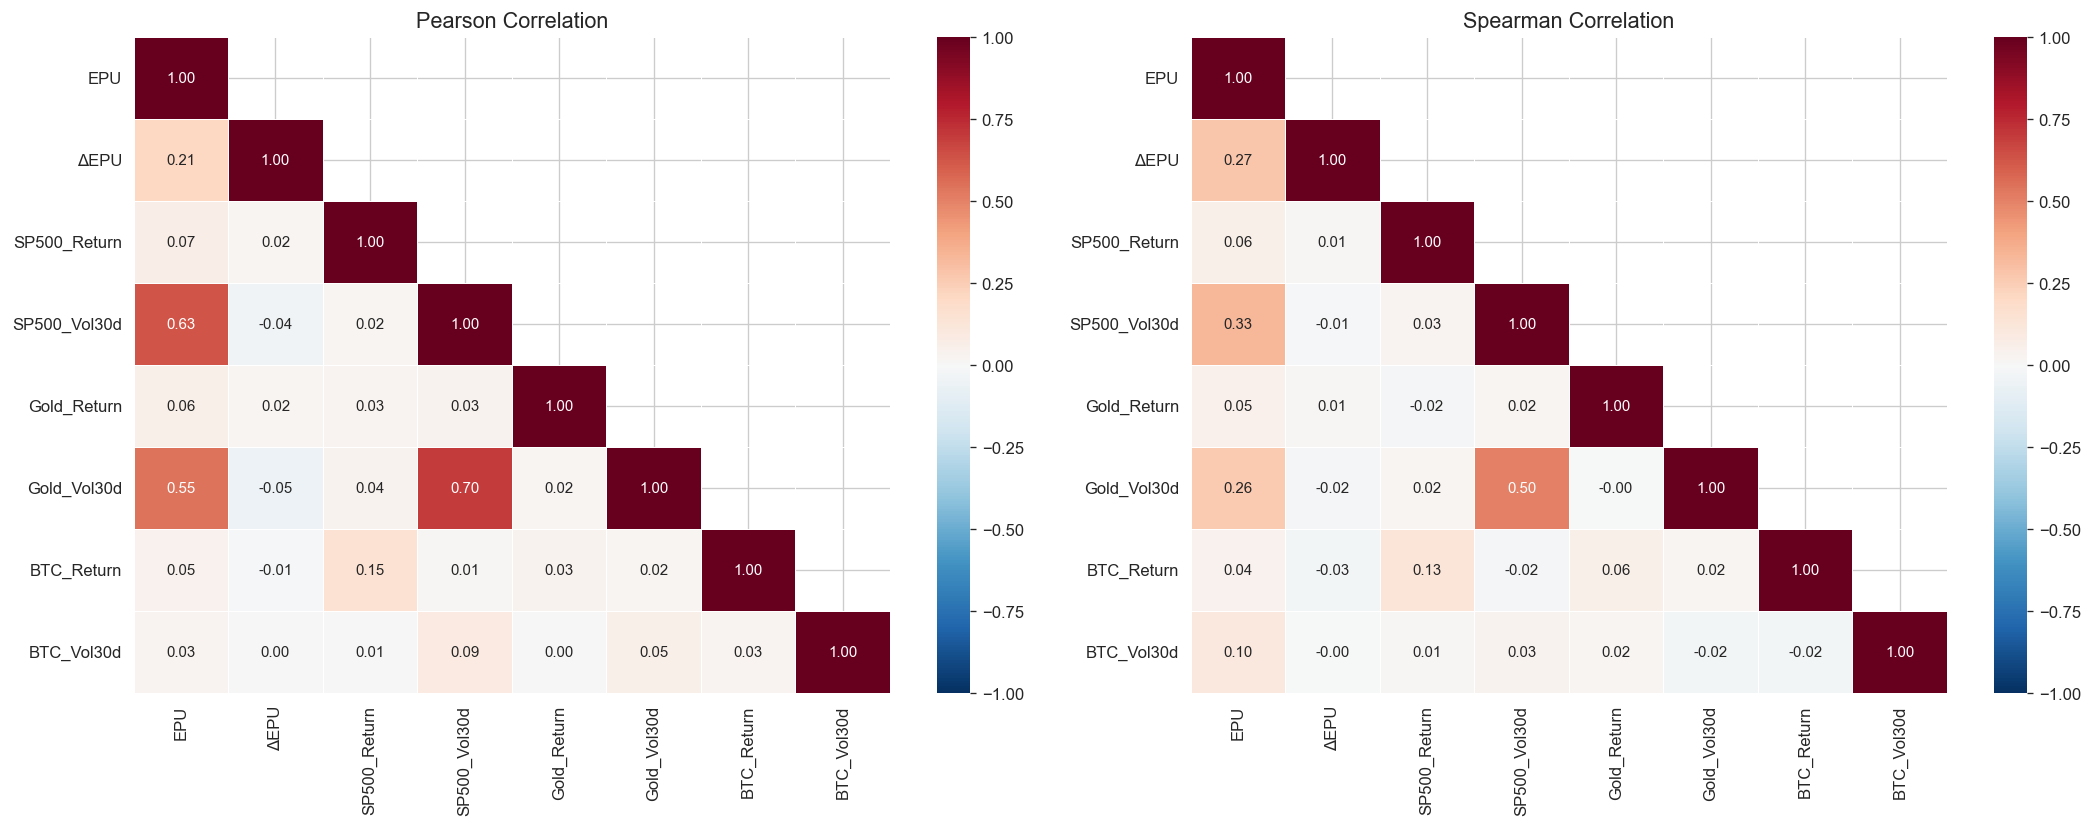

In [12]:
CORR_VARS = ['EPU', 'ΔEPU',
             'SP500_Return', 'SP500_Vol30d',
             'Gold_Return', 'Gold_Vol30d',
             'BTC_Return', 'BTC_Vol30d']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, method, title in zip(axes,
                              ['pearson', 'spearman'],
                              ['Pearson Correlation', 'Spearman Correlation']):
    corr = df[CORR_VARS].corr(method=method)
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
                annot_kws={'size': 9})
    ax.set_title(title, fontsize=13)

plt.tight_layout()
plt.show()

In [13]:
# ── Numeric comparison ─────────────────────────────────────────────
pearson  = df[CORR_VARS].corr(method='pearson')
spearman = df[CORR_VARS].corr(method='spearman')

diff = (spearman - pearson).round(3)
print('Spearman − Pearson (positive → Spearman stronger):')
display(diff)

Spearman − Pearson (positive → Spearman stronger):


,EPU,ΔEPU,SP500_Return,SP500_Vol30d,Gold_Return,Gold_Vol30d,BTC_Return,BTC_Vol30d
EPU,0.000,0.065,-0.006,-0.296,-0.007,-0.285,-0.002,0.079
ΔEPU,0.065,0.000,-0.007,0.030,-0.006,0.033,-0.022,-0.006
SP500_Return,-0.006,-0.007,0.000,0.010,-0.049,-0.023,-0.019,0.005
SP500_Vol30d,-0.296,0.030,0.010,0.000,-0.014,-0.202,-0.029,-0.060
Gold_Return,-0.007,-0.006,-0.049,-0.014,0.000,-0.022,0.028,0.019
Gold_Vol30d,-0.285,0.033,-0.023,-0.202,-0.022,0.000,-0.003,-0.080
BTC_Return,-0.002,-0.022,-0.019,-0.029,0.028,-0.003,0.000,-0.053
BTC_Vol30d,0.079,-0.006,0.005,-0.060,0.019,-0.080,-0.053,0.000


> **Key takeaway:** Where Spearman correlations are materially larger (in absolute value) than Pearson, the association is likely non-linear or driven by extreme observations. This motivates the use of both estimators in the formal analysis.

---
## 5. Quintile Analysis — Uncertainty Regimes

We divide observations into five equal-frequency bins (quintiles) based on EPU and ΔEPU. For each bin we compute the average market volatility and return to check whether the EPU–volatility relationship is **monotonic**, and whether extreme uncertainty (Q5) disproportionately amplifies risk.

In [14]:
def quintile_analysis(df, group_var, targets, labels_prefix='Q'):
    """
    Create quintiles of `group_var` and compute mean/median of `targets`.
    Returns a summary DataFrame.
    """
    tmp = df[[group_var] + targets].dropna()
    tmp['quintile'] = pd.qcut(tmp[group_var], 5,
                              labels=[f'{labels_prefix}{i}' for i in range(1, 6)])
    agg_funcs = {t: ['mean', 'median'] for t in targets}
    agg_funcs[group_var] = ['mean', 'count']
    summary = tmp.groupby('quintile').agg(agg_funcs).round(6)
    return summary, tmp

In [15]:
VOL_TARGETS  = ['SP500_Vol30d', 'Gold_Vol30d', 'BTC_Vol30d']
RET_TARGETS  = ['SP500_Return', 'Gold_Return', 'BTC_Return']
ALL_TARGETS  = VOL_TARGETS + RET_TARGETS

for gvar, title in [('EPU', 'EPU Level'), ('ΔEPU', 'ΔEPU Shock')]:
    summary, tmp = quintile_analysis(df.reset_index(), gvar, ALL_TARGETS)
    print(f'\n{"═" * 80}')
    print(f'  Quintile Summary — {title}')
    print(f'{"═" * 80}')
    display(summary)


════════════════════════════════════════════════════════════════════════════════
  Quintile Summary — EPU Level
════════════════════════════════════════════════════════════════════════════════


SP500_Vol30d           Gold_Vol30d           BTC_Vol30d            \
                 mean    median        mean    median       mean    median   
quintile                                                                     
Q1           0.007431  0.006819    0.008719  0.008396   0.035819  0.028412   
Q2           0.008069  0.007462    0.008519  0.008239   0.043348  0.031972   
Q3           0.008420  0.007432    0.008587  0.008198   0.036511  0.033268   
Q4           0.009260  0.008151    0.009129  0.008705   0.037322  0.033177   
Q5           0.014366  0.011677    0.011381  0.010225   0.036359  0.032915   

         SP500_Return           Gold_Return           BTC_Return            \
                 mean    median        mean    median       mean    median   
quintile                                                                     
Q1          -0.000123  0.000017   -0.000241 -0.000459  -0.001486  0.000028   
Q2           0.000116  0.000721   -0.000051 -0.000343  -0.003534 -0.001144   
Q3          -0.000094  0.000477    0.000274  0.000671   0.007224  0.001425   
Q4           0.000559  0.000042    0.000235  0.000239  -0.002933  0.000421   
Q5           0.001152  0.002261    0.000997  0.000872   0.005229  0.004752   

                 EPU        
                mean count  
quintile                    
Q1         41.684072   442  
Q2         67.406236   441  
Q3         91.960950   442  
Q4        128.424195   441  
Q5        265.099231   442


════════════════════════════════════════════════════════════════════════════════
  Quintile Summary — ΔEPU Shock
════════════════════════════════════════════════════════════════════════════════


SP500_Vol30d           Gold_Vol30d           BTC_Vol30d            \
                 mean    median        mean    median       mean    median   
quintile                                                                     
Q1           0.010824  0.008847    0.009939  0.009168   0.036040  0.032579   
Q2           0.008763  0.007609    0.008822  0.008438   0.038084  0.032405   
Q3           0.008504  0.007614    0.008895  0.008494   0.039204  0.031411   
Q4           0.009083  0.007781    0.009119  0.008477   0.038891  0.032256   
Q5           0.010373  0.008167    0.009561  0.008894   0.037132  0.032417   

         SP500_Return           Gold_Return           BTC_Return            \
                 mean    median        mean    median       mean    median   
quintile                                                                     
Q1           0.000009  0.000281    0.000535  0.000854   0.003878  0.003590   
Q2           0.000284  0.000687   -0.000462 -0.000339   0.002877  0.000701   
Q3           0.000237  0.000517    0.000101  0.000040  -0.002196 -0.000567   
Q4           0.000158  0.000559    0.000745  0.000000  -0.001483 -0.000385   
Q5           0.000922  0.000790    0.000296  0.000298   0.001442  0.000663   

               ΔEPU        
               mean count  
quintile                   
Q1       -99.237172   442  
Q2       -31.331134   441  
Q3        -7.617466   442  
Q4        13.796190   441  
Q5        72.021244   442

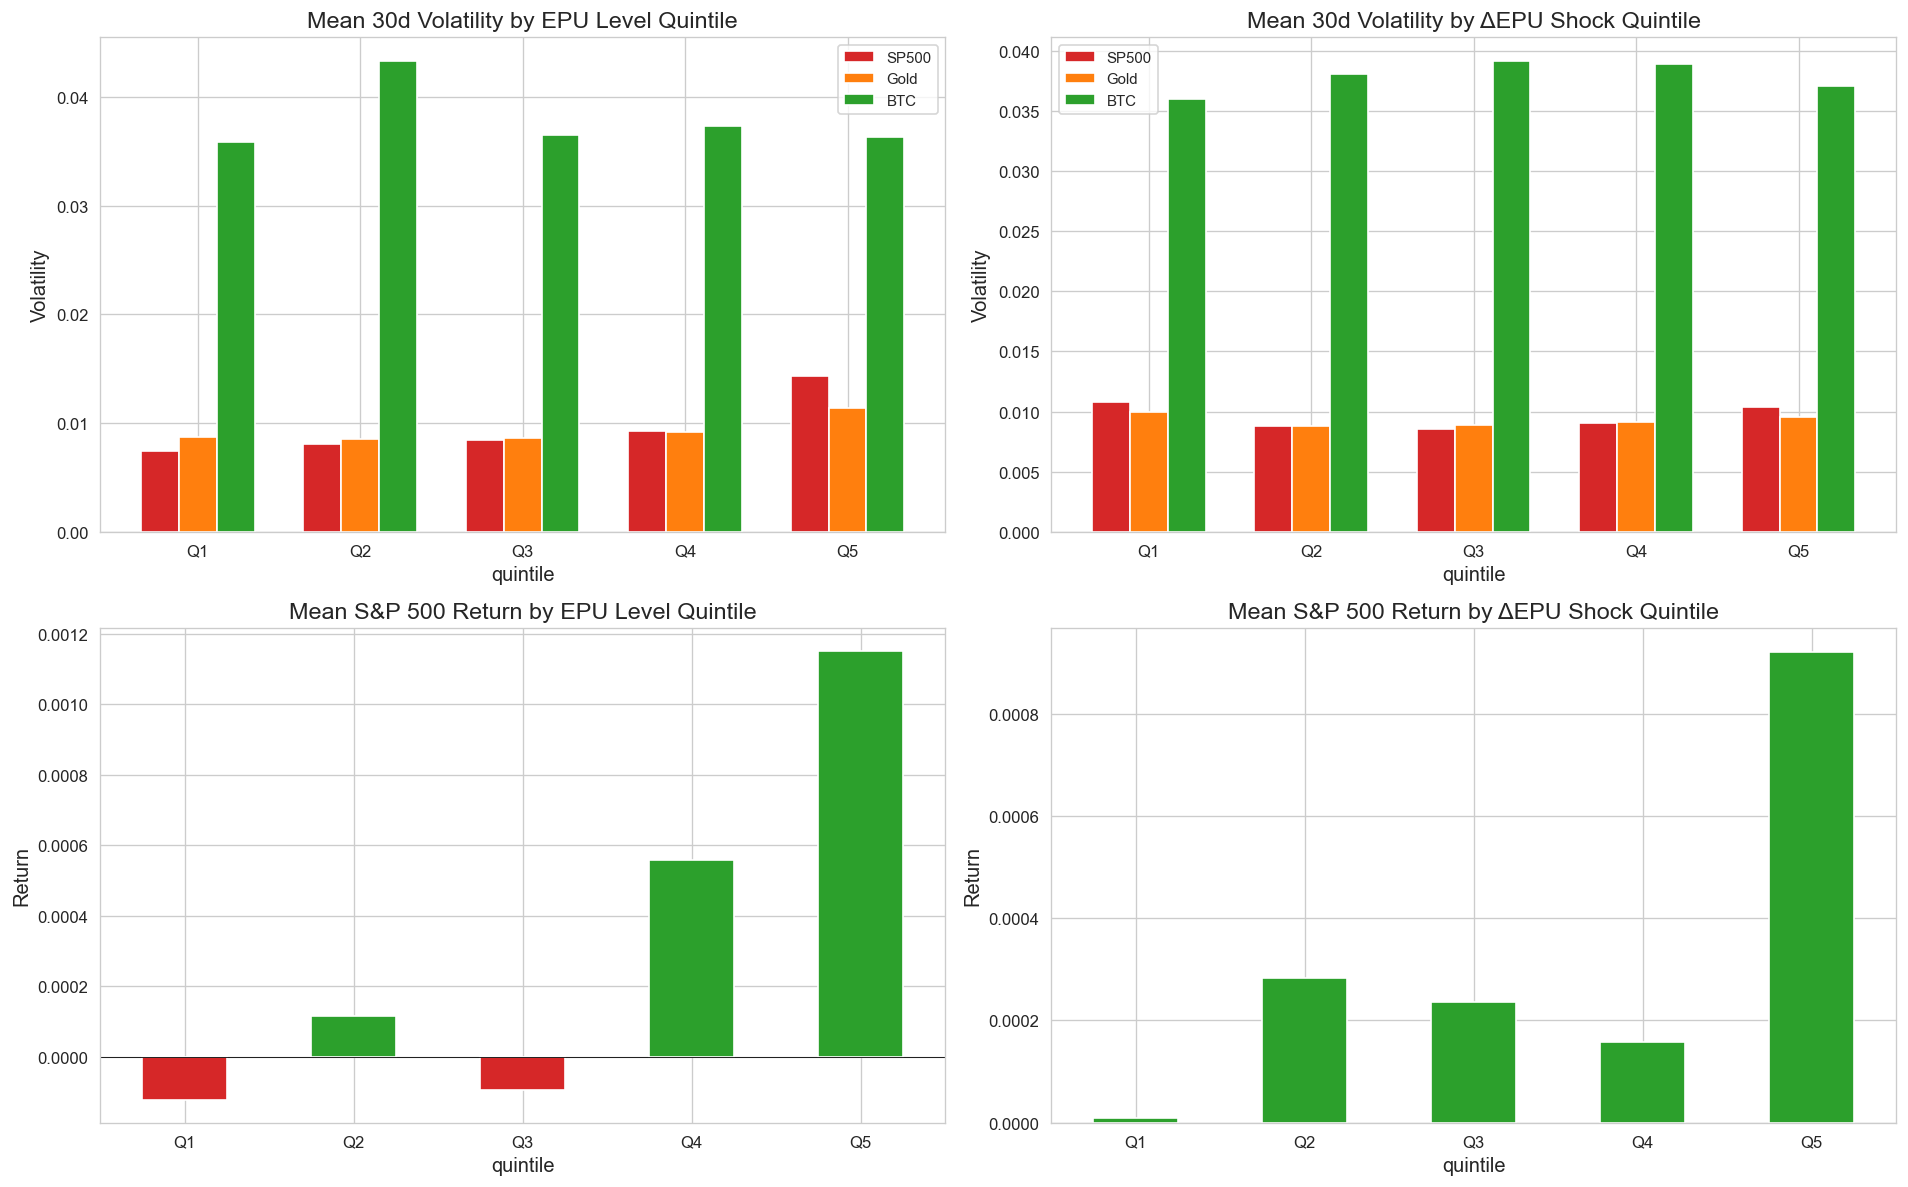

In [16]:
# ── Bar plots: volatility and return by quintile ───────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col_idx, (gvar, gvar_label) in enumerate([('EPU', 'EPU Level'),
                                                ('ΔEPU', 'ΔEPU Shock')]):
    _, tmp = quintile_analysis(df.reset_index(), gvar, ALL_TARGETS)

    # Volatility by quintile
    ax_v = axes[0, col_idx]
    vol_means = tmp.groupby('quintile')[VOL_TARGETS].mean()
    vol_means.columns = [a.replace('_Vol30d', '') for a in VOL_TARGETS]
    vol_means.plot.bar(ax=ax_v, rot=0, width=0.7,
                       color=[COLORS['sp500'], COLORS['gold'], COLORS['btc']])
    ax_v.set_title(f'Mean 30d Volatility by {gvar_label} Quintile')
    ax_v.set_ylabel('Volatility')
    ax_v.legend(fontsize=9)

    # S&P 500 Return by quintile
    ax_r = axes[1, col_idx]
    ret_means = tmp.groupby('quintile')['SP500_Return'].mean()
    colors = ['#2ca02c' if v >= 0 else '#d62728' for v in ret_means]
    ret_means.plot.bar(ax=ax_r, color=colors, rot=0, width=0.5)
    ax_r.axhline(0, color='black', linewidth=0.5)
    ax_r.set_title(f'Mean S&P 500 Return by {gvar_label} Quintile')
    ax_r.set_ylabel('Return')

plt.tight_layout()
plt.show()

In [17]:
# ── Sample size per quintile ───────────────────────────────────────
for gvar in ['EPU', 'ΔEPU']:
    tmp = df[[gvar]].dropna().copy()
    tmp['quintile'] = pd.qcut(tmp[gvar], 5, labels=[f'Q{i}' for i in range(1, 6)])
    print(f'\nSample sizes — {gvar}:')
    print(tmp['quintile'].value_counts().sort_index())


Sample sizes — EPU:
quintile
Q1    446
Q2    445
Q3    445
Q4    445
Q5    446
Name: count, dtype: int64

Sample sizes — ΔEPU:
quintile
Q1    446
Q2    445
Q3    445
Q4    445
Q5    446
Name: count, dtype: int64


> **Interpretation:** A monotonically increasing pattern of volatility across EPU quintiles would be consistent with the *uncertainty–volatility hypothesis*. If the effect is concentrated in Q5 (highest uncertainty), the relationship may be non-linear and driven by tail events rather than a smooth gradient. Return patterns across quintiles may reveal an *uncertainty premium* (lower returns under higher uncertainty).

---
## 6. Lead-Lag Analysis (Cross-Correlations with Lags)

A positive correlation at lag *k* between EPU$_{t-k}$ and Vol$_t$ would suggest that elevated policy uncertainty **precedes** higher market volatility by *k* days — a prerequisite for predictive modelling.

We compute correlations for lags 0 through 30 days and identify the lag with the strongest absolute association.

In [18]:
def lead_lag_corr(df, x_col, y_col, max_lag=30, method='pearson'):
    """
    Compute correlation between x_{t-k} and y_t for k = 0, ..., max_lag.
    Returns a DataFrame with lag, correlation, and p-value.
    """
    from scipy.stats import pearsonr, spearmanr
    corr_func = pearsonr if method == 'pearson' else spearmanr
    results = []
    for k in range(max_lag + 1):
        x_lagged = df[x_col].shift(k)
        valid = df[[y_col]].assign(x_lag=x_lagged).dropna()
        if len(valid) < 50:
            continue
        r, p = corr_func(valid['x_lag'], valid[y_col])
        results.append({'lag': k, 'corr': r, 'pvalue': p})
    return pd.DataFrame(results)

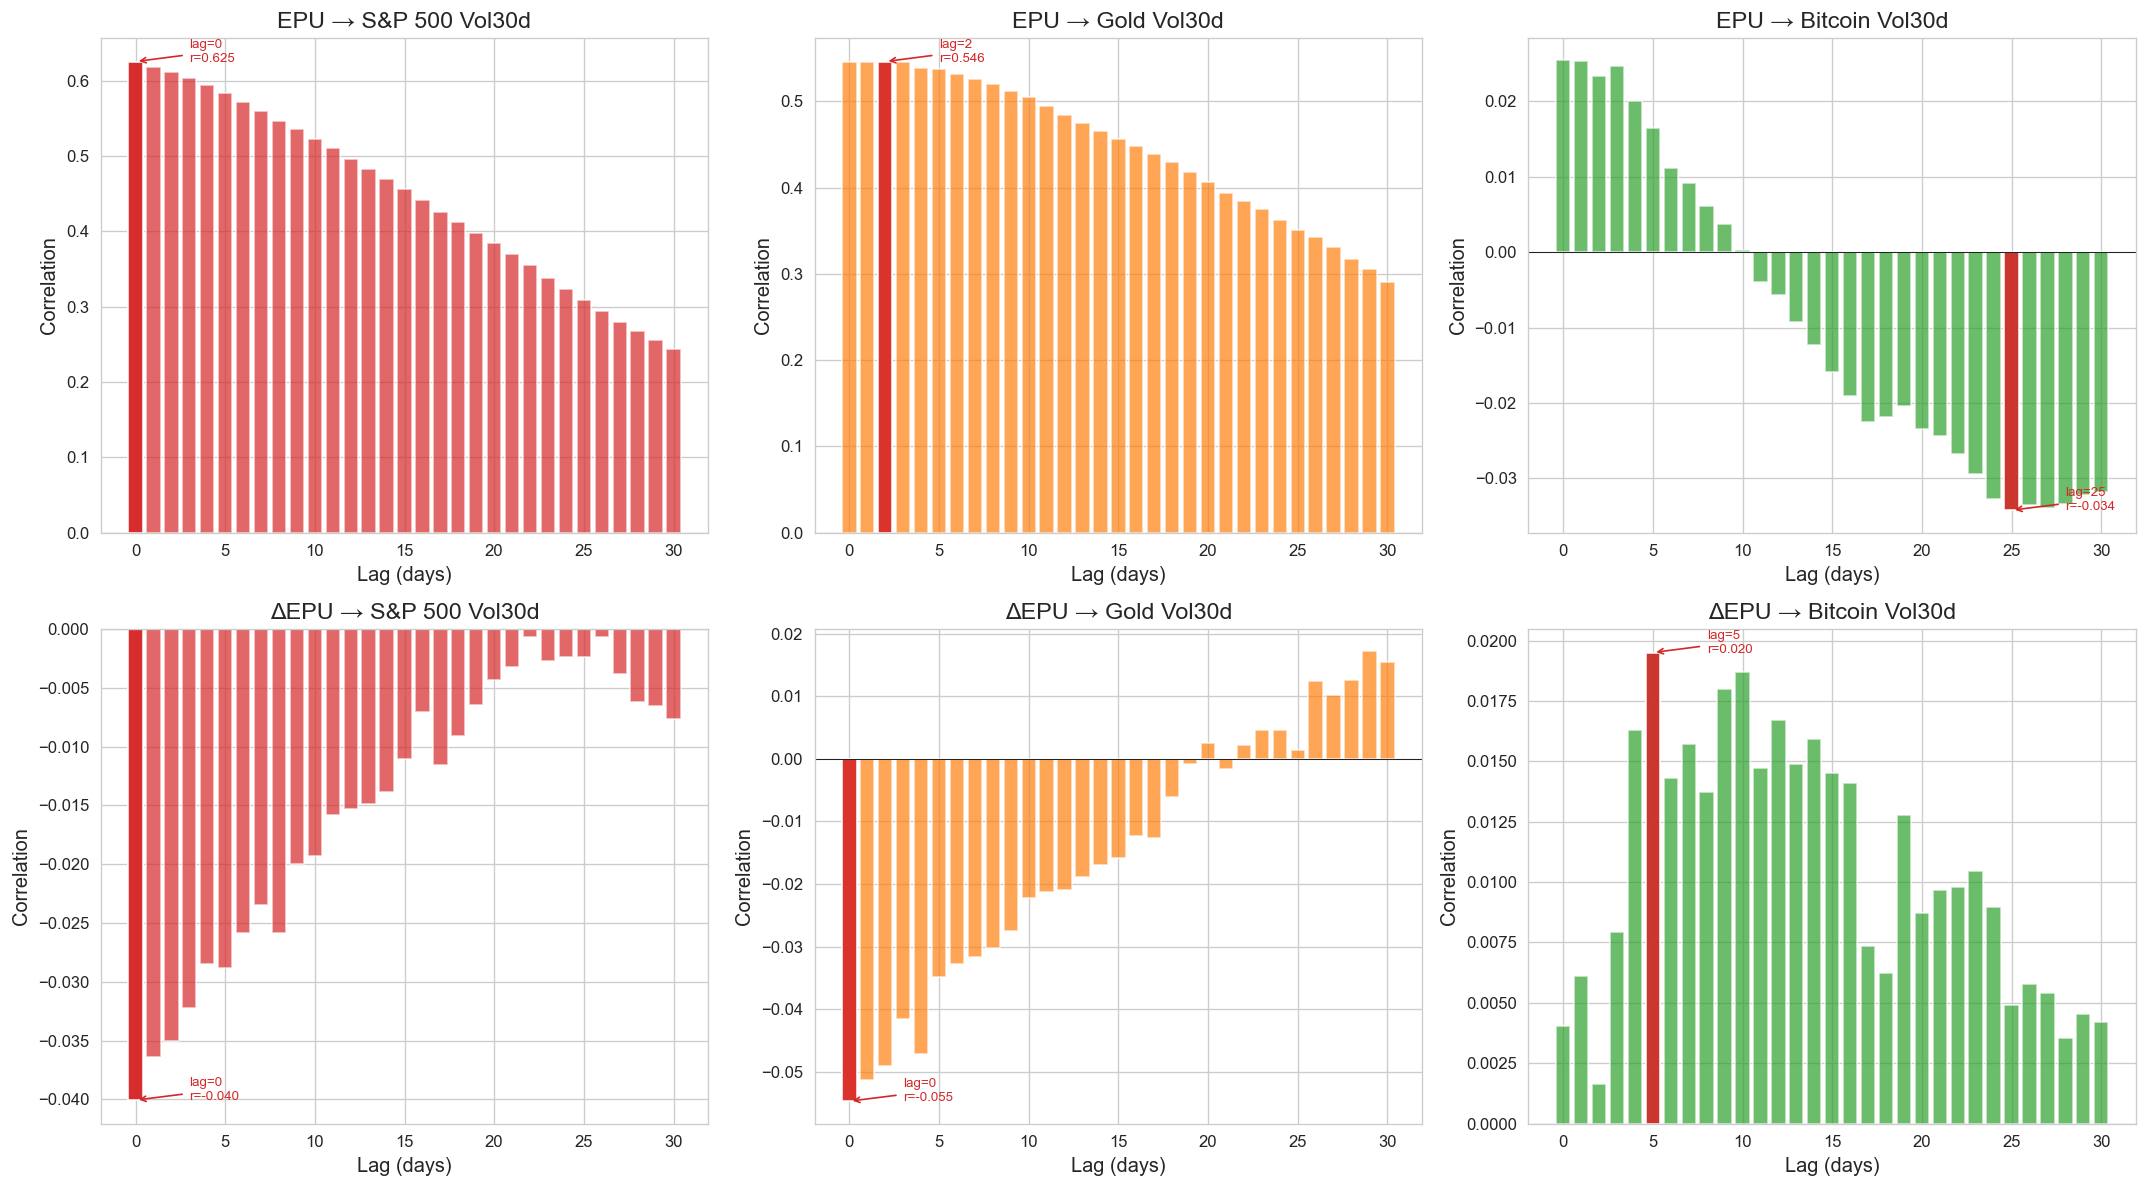

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col_idx, (asset, meta) in enumerate(ASSET_META.items()):
    vol_col = f'{asset}_Vol30d'

    for row_idx, (epu_var, epu_label) in enumerate([('EPU', 'EPU'),
                                                     ('ΔEPU', 'ΔEPU')]):
        ax = axes[row_idx, col_idx]
        ll = lead_lag_corr(df, epu_var, vol_col, max_lag=30)
        ax.bar(ll['lag'], ll['corr'], color=meta['color'], alpha=0.7, width=0.8)
        ax.axhline(0, color='black', linewidth=0.5)

        # Mark max |corr|
        best_idx = ll['corr'].abs().idxmax()
        best_lag = ll.loc[best_idx, 'lag']
        best_r   = ll.loc[best_idx, 'corr']
        ax.bar(best_lag, best_r, color='#d62728', alpha=0.9, width=0.8)
        ax.annotate(f'lag={best_lag}\nr={best_r:.3f}',
                    xy=(best_lag, best_r),
                    xytext=(best_lag + 3, best_r),
                    fontsize=8, color='#d62728',
                    arrowprops=dict(arrowstyle='->', color='#d62728'))

        ax.set_title(f'{epu_label} → {meta["label"]} Vol30d')
        ax.set_xlabel('Lag (days)')
        ax.set_ylabel('Correlation')

plt.tight_layout()
plt.show()

In [20]:
# ── Numeric lead-lag summary (first 10 lags) ───────────────────────
for asset, meta in ASSET_META.items():
    vol_col = f'{asset}_Vol30d'
    for epu_var in ['EPU', 'ΔEPU']:
        ll = lead_lag_corr(df, epu_var, vol_col, max_lag=10)
        print(f'\n{epu_var} → {meta["label"]} Vol30d')
        display(ll.set_index('lag').round(4).T)


EPU → S&P 500 Vol30d


lag,0,1,2,3,4,5,6,7,8,9,10
corr,0.6255,0.6183,0.6117,0.6041,0.5948,0.5836,0.5722,0.5595,0.5467,0.5357,0.5224
pvalue,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000



ΔEPU → S&P 500 Vol30d


lag,0,1,2,3,4,5,6,7,8,9,10
corr,-0.0401,-0.0364,-0.0350,-0.0323,-0.0285,-0.0288,-0.0258,-0.0235,-0.0259,-0.0200,-0.0193
pvalue,0.0587,0.0857,0.0988,0.1283,0.1796,0.1745,0.2238,0.2689,0.2231,0.3464,0.3631



EPU → Gold Vol30d


...

lag,0,1,2,3,4,5,6,7,8,9,10
corr,-0.0547,-0.0513,-0.0491,-0.0416,-0.0472,-0.0348,-0.0329,-0.0317,-0.0303,-0.0276,-0.0223
pvalue,0.0098,0.0155,0.0204,0.0497,0.0261,0.1008,0.1215,0.1351,0.1542,0.1942,0.2942



EPU → Bitcoin Vol30d


lag,0,1,2,3,4,5,6,7,8,9,10
corr,0.0254,0.0254,0.0233,0.0247,0.0201,0.0165,0.0112,0.0092,0.0061,0.0037,0.0004
pvalue,0.2321,0.2334,0.2733,0.2458,0.3449,0.4385,0.5977,0.6662,0.7751,0.8624,0.9866



ΔEPU → Bitcoin Vol30d


lag,0,1,2,3,4,5,6,7,8,9,10
corr,0.0040,0.0061,0.0016,0.0079,0.0163,0.0195,0.0143,0.0157,0.0137,0.018,0.0187
pvalue,0.8496,0.7747,0.9390,0.7095,0.4444,0.3597,0.5018,0.4610,0.5194,0.398,0.3796


> **Interpretation:**  
> - If the highest absolute correlation appears at **lag 0**, the relationship is predominantly contemporaneous.  
> - A peak at **lags 1–7** is encouraging for short-term volatility forecasting.  
> - Different assets may exhibit different lag structures, reflecting varying sensitivity to uncertainty signals.

---
## 7. Rolling Correlations — Time-Varying Association

Full-sample correlations can mask substantial temporal variation. Rolling-window correlations reveal whether the EPU–volatility association strengthens during crises and weakens in calm regimes.

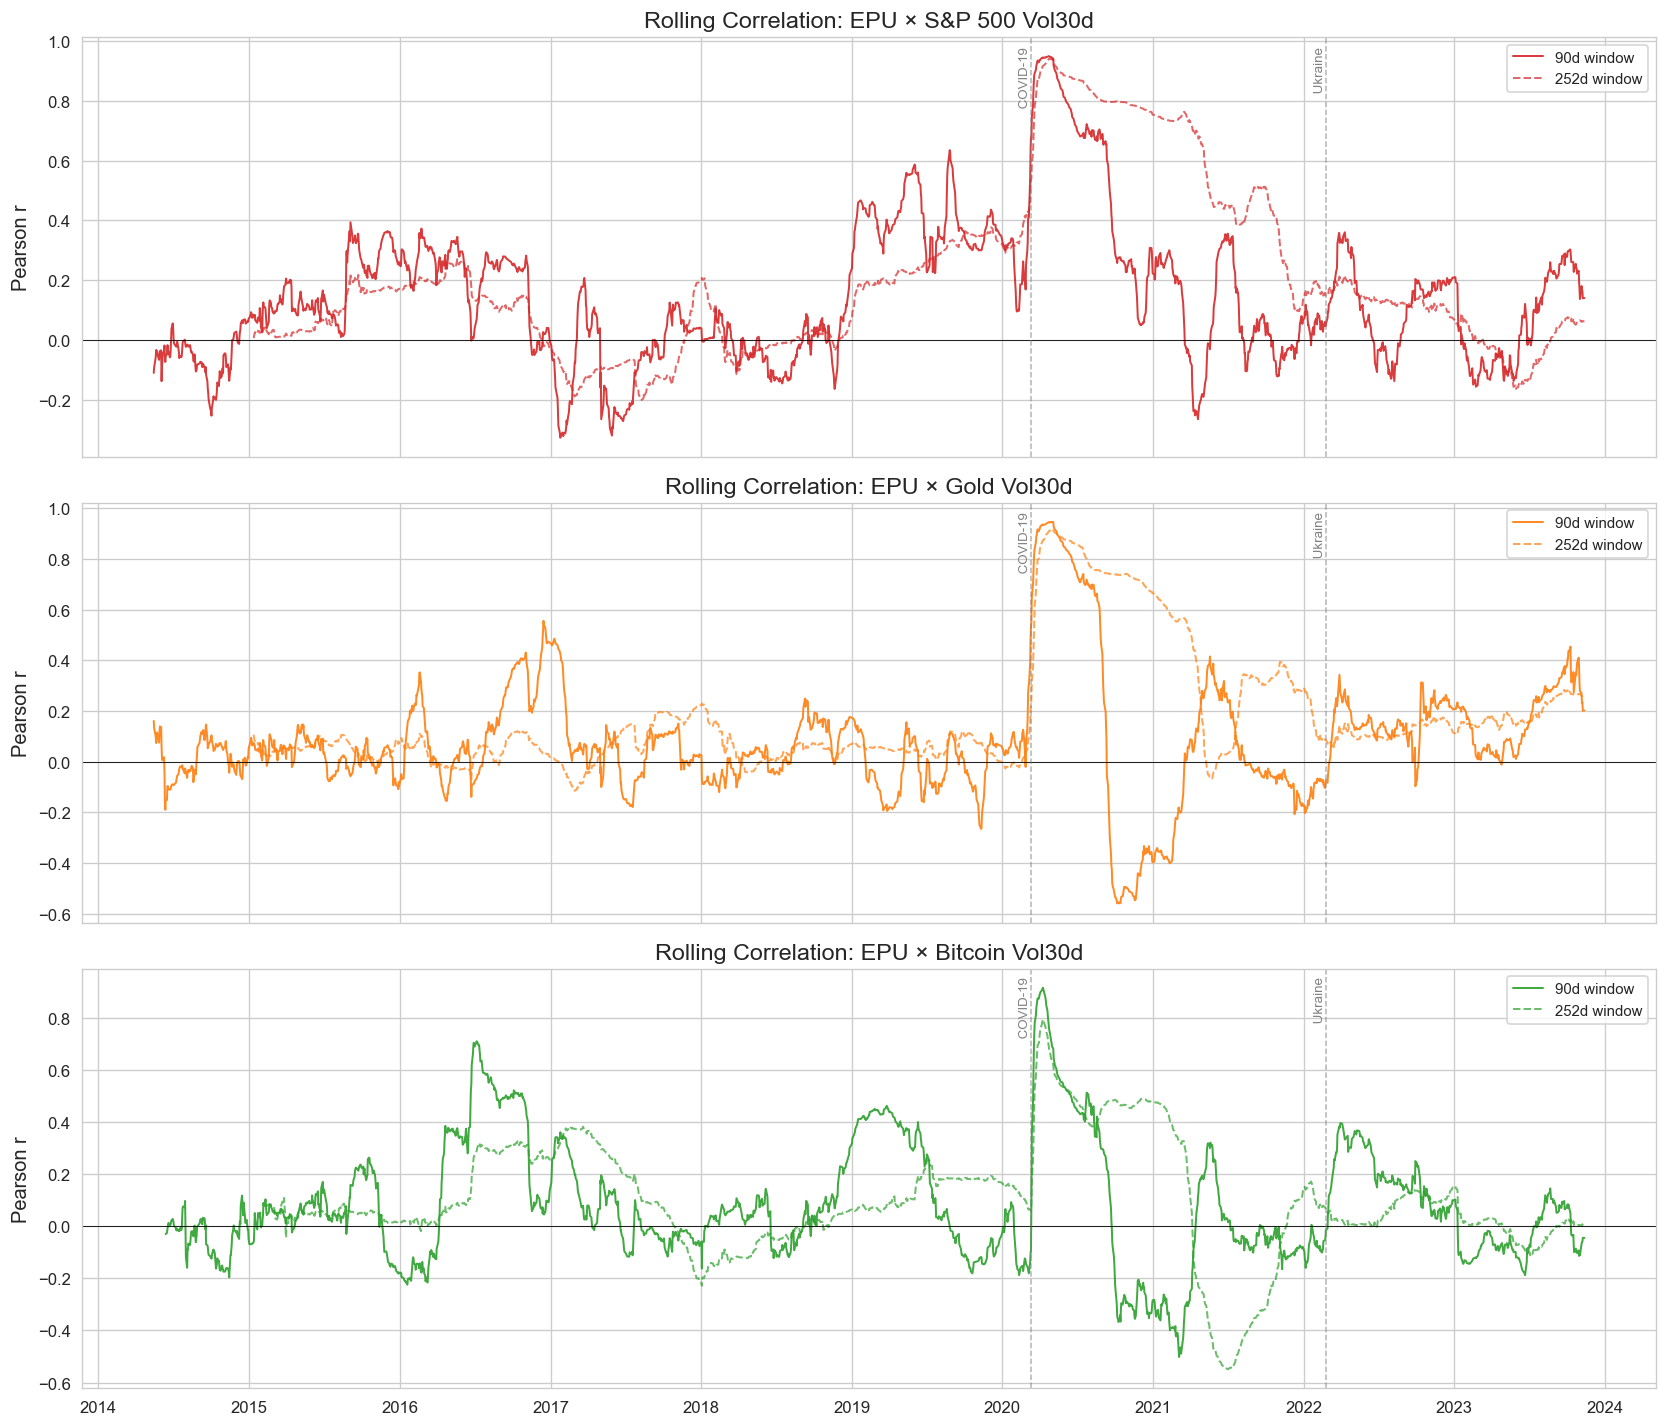

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for ax, (asset, meta) in zip(axes, ASSET_META.items()):
    vol_col = f'{asset}_Vol30d'

    for window, ls, alpha_val in [(90, '-', 0.9), (252, '--', 0.7)]:
        rolling_corr = df['EPU'].rolling(window).corr(df[vol_col])
        ax.plot(df.index, rolling_corr, linewidth=1.2, linestyle=ls,
                alpha=alpha_val, label=f'{window}d window', color=meta['color'])

    ax.axhline(0, color='black', linewidth=0.5)
    add_crisis_lines(ax)
    ax.set_ylabel('Pearson r')
    ax.set_title(f'Rolling Correlation: EPU × {meta["label"]} Vol30d')
    ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

> **Interpretation:** Episodes where the rolling correlation spikes upward coincide with periods of market stress (e.g., GFC, COVID-19). The EPU–volatility association is regime-dependent — an important consideration for model specification. Different assets may show distinct correlation dynamics.

---
## 8. Subperiod Analysis — Structural Robustness

To test whether the observed associations are stable over time, we split the sample into non-overlapping subperiods:

| Period | Range | Key characteristics |
|--------|-------|---------------------|
| I | start – 2012 | GFC, post-crisis recovery |
| II | 2013 – 2019 | Low-volatility regime, trade tensions |
| III | 2020 – present | COVID-19, inflation, Ukraine |

For each subperiod we report correlations and average levels of volatility and EPU.

In [22]:
SUBPERIODS = {
    'I  (start–2012)': (df.index.min().strftime('%Y-%m-%d'), '2012-12-31'),
    'II (2013–2019)':  ('2013-01-01', '2019-12-31'),
    'III (2020–last)': ('2020-01-01', df.index.max().strftime('%Y-%m-%d')),
}

rows = []
for label, (start, end) in SUBPERIODS.items():
    sub = df.loc[start:end].dropna(subset=['EPU', 'SP500_Vol30d'])
    row = {
        'Period': label,
        'N': len(sub),
        'EPU_mean': sub['EPU'].mean(),
    }
    for asset in ['SP500', 'Gold', 'BTC']:
        vol_col = f'{asset}_Vol30d'
        if vol_col in sub.columns:
            valid = sub[['EPU', vol_col]].dropna()
            row[f'{asset}_Vol_mean'] = valid[vol_col].mean()
            row[f'Corr(EPU,{asset}Vol)_pearson']  = valid['EPU'].corr(valid[vol_col], method='pearson')
            row[f'Corr(EPU,{asset}Vol)_spearman'] = valid['EPU'].corr(valid[vol_col], method='spearman')
    rows.append(row)

subperiod_table = pd.DataFrame(rows).set_index('Period')
display(subperiod_table.round(4))

,N,EPU_mean,SP500_Vol_mean,"Corr(EPU,SP500Vol)_pearson","Corr(EPU,SP500Vol)_spearman",Gold_Vol_mean,"Corr(EPU,GoldVol)_pearson","Corr(EPU,GoldVol)_spearman",BTC_Vol_mean,"Corr(EPU,BTCVol)_pearson","Corr(EPU,BTCVol)_spearman"
Period,,,,,,,,,,,
I (start–2012),0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
II (2013–2019),1343,80.3005,0.0076,0.0433,-0.0281,0.0085,-0.0835,-0.1114,0.0405,0.0144,0.1643
III (2020–last),884,177.1076,0.0123,0.6614,0.3831,0.0105,0.6197,0.4363,0.0339,0.3100,0.1044


> **Interpretation:** Consistent sign and magnitude of the EPU–volatility correlation across subperiods supports a **robust association**. Substantial variation may indicate a **structural break**. Note that the post-2020 subsample is heavily influenced by the COVID-19 shock, and Bitcoin data availability may differ across subperiods.

---
## 9. EDA Conclusions

The following bullet points synthesise the main patterns uncovered in this exploratory analysis. They serve as motivation and guidance for the predictive-modelling stage (Phase 3).

In [23]:
# ── Automated summary statistics for conclusions ───────────────────
print('━' * 70)
print('  SUMMARY STATISTICS FOR CONCLUSIONS')
print('━' * 70)

# 1. Full-sample correlations
print('\n1. Full-sample Pearson correlations (EPU vs Vol30d):')
for asset, meta in ASSET_META.items():
    vol_col = f'{asset}_Vol30d'
    r = df['EPU'].corr(df[vol_col])
    print(f'   EPU ↔ {meta["label"]:>8} Vol30d : {r:.4f}')

# 2. Best lag per asset
print('\n2. Best lag (EPU → Vol30d):')
for asset, meta in ASSET_META.items():
    vol_col = f'{asset}_Vol30d'
    ll = lead_lag_corr(df, 'EPU', vol_col, max_lag=30)
    best = ll.loc[ll['corr'].abs().idxmax()]
    print(f'   {meta["label"]:>8} : lag={int(best["lag"])}d, r={best["corr"]:.4f}')

# 3. Volatility Q5/Q1 ratio
print('\n3. Vol30d ratio Q5/Q1 (EPU quintiles):')
_, tmp_q = quintile_analysis(df.reset_index(), 'EPU', VOL_TARGETS)
for vol_col in VOL_TARGETS:
    v1 = tmp_q[tmp_q['quintile'] == 'Q1'][vol_col].mean()
    v5 = tmp_q[tmp_q['quintile'] == 'Q5'][vol_col].mean()
    asset_name = vol_col.replace('_Vol30d', '')
    print(f'   {asset_name:>8} : Q1={v1:.6f}, Q5={v5:.6f}, ratio={v5/v1:.2f}x')

# 4. Sample size
print(f'\n4. Total observations: {len(df)}')
print(f'   Complete cases (EPU+SP500): {df[["EPU", "SP500_Vol30d"]].dropna().shape[0]}')

print('\n' + '━' * 70)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SUMMARY STATISTICS FOR CONCLUSIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. Full-sample Pearson correlations (EPU vs Vol30d):
   EPU ↔  S&P 500 Vol30d : 0.6255
   EPU ↔     Gold Vol30d : 0.5450
   EPU ↔  Bitcoin Vol30d : 0.0254

2. Best lag (EPU → Vol30d):
    S&P 500 : lag=0d, r=0.6255
       Gold : lag=2d, r=0.5460
    Bitcoin : lag=25d, r=-0.0342

3. Vol30d ratio Q5/Q1 (EPU quintiles):
      SP500 : Q1=0.007431, Q5=0.014366, ratio=1.93x
       Gold : Q1=0.008719, Q5=0.011381, ratio=1.31x
        BTC : Q1=0.035819, Q5=0.036359, ratio=1.02x

4. Total observations: 2227
   Complete cases (EPU+SP500): 2227

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
*End of Phase 2: Exploratory Data Analysis — US EPU × Multi-Asset Volatility*